In [1]:
# Install Tensor flow hub
# !pip install tensorflow_hub 


In [2]:
# !pip install pillow

In [4]:
import numpy as np
import cv2
import PIL.Image as Image
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

C:\Users\sangambhondele\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\sangambhondele\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [5]:
IMAGE_SHAPE=(224,224)
base_model=tf.keras.applications.MobileNetV2(
 input_shape=IMAGE_SHAPE+(3,),
 include_top=True,
 weights='imagenet'    
)

In [6]:
model=tf.keras.Sequential([base_model])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1000)                │       3,538,984 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

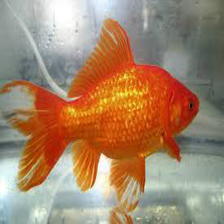

In [7]:
gold_fish=Image.open("goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [8]:
gold_fish=np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [9]:
gold_fish[np.newaxis]

array([[[[0.5254902 , 0.56862745, 0.55294118],
         [0.52941176, 0.57254902, 0.55686275],
         [0.54117647, 0.58431373, 0.56862745],
         ...,
         [0.38431373, 0.39215686, 0.32941176],
         [0.37254902, 0.38039216, 0.3254902 ],
         [0.36862745, 0.37647059, 0.32156863]],

        [[0.53333333, 0.57647059, 0.56078431],
         [0.53333333, 0.57647059, 0.56078431],
         [0.54509804, 0.58823529, 0.57254902],
         ...,
         [0.38431373, 0.39607843, 0.32941176],
         [0.37254902, 0.38039216, 0.3254902 ],
         [0.36862745, 0.37647059, 0.32156863]],

        [[0.54509804, 0.58823529, 0.57254902],
         [0.54509804, 0.58823529, 0.57254902],
         [0.54901961, 0.59215686, 0.57647059],
         ...,
         [0.38823529, 0.39607843, 0.33333333],
         [0.37254902, 0.38039216, 0.3254902 ],
         [0.36862745, 0.37647059, 0.32156863]],

        ...,

        [[0.49411765, 0.60784314, 0.62352941],
         [0.49803922, 0.61176471, 0.63529412]

In [10]:
result=model.predict(gold_fish[np.newaxis,...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


(1, 1000)

In [11]:
predicted_label_index=np.argmax(result)
predicted_label_index

1

In [12]:
image_labels=[]
with open("ImageNetLabels.txt","r") as f:
    image_labels=f.read().splitlines()
image_labels[:5]    

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [13]:
image_labels[predicted_label_index+1]

'goldfish'

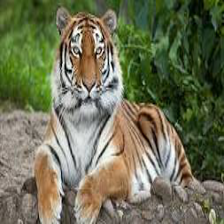

In [14]:
tiger=Image.open("tiger.jpg").resize(IMAGE_SHAPE)
tiger

In [15]:
tiger=np.array(tiger)/255.0
tiger.shape

(224, 224, 3)

In [16]:
tiger[np.newaxis]

array([[[[0.21176471, 0.25490196, 0.12941176],
         [0.23137255, 0.2745098 , 0.14117647],
         [0.24705882, 0.29019608, 0.15686275],
         ...,
         [0.17254902, 0.25098039, 0.05098039],
         [0.11764706, 0.18431373, 0.00784314],
         [0.03921569, 0.10588235, 0.        ]],

        [[0.21960784, 0.2627451 , 0.13333333],
         [0.23529412, 0.27843137, 0.14509804],
         [0.25098039, 0.29411765, 0.16078431],
         ...,
         [0.18823529, 0.2627451 , 0.0627451 ],
         [0.14901961, 0.22352941, 0.03921569],
         [0.09411765, 0.16470588, 0.01960784]],

        [[0.22745098, 0.27058824, 0.1372549 ],
         [0.24313725, 0.28627451, 0.14901961],
         [0.25490196, 0.30196078, 0.16078431],
         ...,
         [0.18431373, 0.2627451 , 0.05882353],
         [0.18823529, 0.26666667, 0.07058824],
         [0.16862745, 0.24313725, 0.04705882]],

        ...,

        [[0.38431373, 0.35294118, 0.30980392],
         [0.35686275, 0.3254902 , 0.28235294]

In [17]:
tiger_result=model.predict(tiger[np.newaxis,...])
tiger_result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


(1, 1000)

In [18]:
predicted_label_index_tiger=np.argmax(tiger_result)
predicted_label_index_tiger

292

In [19]:
image_labels[predicted_label_index_tiger+1]

'tiger'

In [20]:
#Load Flowers dataset

In [21]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [81]:
data_dir

WindowsPath('datasets/flower_photos')

In [82]:
import pathlib
data_dir=pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [83]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [84]:
image_count=len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [85]:
roses=list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

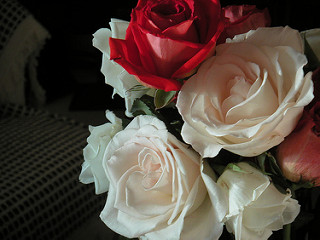

In [59]:
import PIL
PIL.Image.open(str(roses[1]))

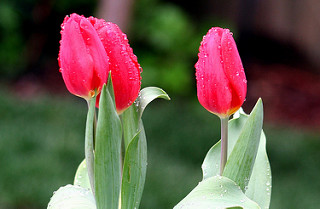

In [60]:
tulips=list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [61]:
# Read flowers images from disk into numpy array using opencv

In [62]:
flowers_image_dict={
    'roses':list(data_dir.glob('roses/*')),
    'daisy':list(data_dir.glob('daisy/*')),
    'dandelion':list(data_dir.glob('dandelion/*')),
    'sunflowers':list(data_dir.glob('sunflowers/*')),
    'tulips':list(data_dir.glob('tulips/*')),
}

In [63]:
flowers_label_dict={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4
}

In [64]:
flowers_image_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [65]:
str(flowers_image_dict['roses'][0])

'datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [66]:
img=cv2.imread(str(flowers_image_dict['roses'][0]))

In [67]:
img.shape

(240, 179, 3)

In [68]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [114]:
X, y = [], []

for flower_name, images in flowers_image_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        
       
        if img is not None:
            resized_img = cv2.resize(img, (224, 224))
            X.append(resized_img)
            y.append(flowers_label_dict[flower_name])
        else:
            
            print(f"Warning: Image not loaded -> {image}")


print(f"Total Images Loaded: {len(X)}")

Total Images Loaded: 3670


In [80]:
X, y = [], []

for flower_name, images in flowers_image_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img =cv2.resize(img, (224, 224))
        X.append(resized_img)
        y.append(flowers_label_dict[flower_name])

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'


In [96]:
X=np.array(X)
y=np.array(y)

In [97]:
# Train  test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

In [98]:
# Preprocessing :scale images
X_train_scaled=X_train/225
X_test_scaled=X_test/255


In [99]:
X[0].shape

(224, 224, 3)

In [100]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [102]:
x0_resized=cv2.resize(X[0],IMAGE_SHAPE)
x1_resized=cv2.resize(X[1],IMAGE_SHAPE)
x2_resized=cv2.resize(X[2],IMAGE_SHAPE)

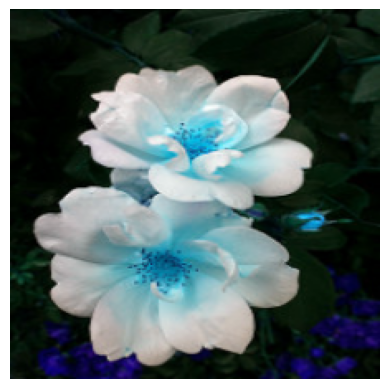

In [103]:
plt.axis('off')
plt.imshow(X[0])

In [104]:
predicted=model.predict(np.array([x0_resized,x1_resized,x2_resized]))
predicted=np.argmax(predicted,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [105]:
predicted

array([794, 721, 443], dtype=int64)

In [107]:
image_labels[795]

'shower curtain'

In [108]:
# Now take pre-trained model and retrain it using flowers images

In [110]:
import tensorflow as tf 
num_of_flowers=5

base_model=tf.keras.applications.MobileNetV2(
  input_shape=(224,224,3),
  include_top=False,
    weights='imagenet',
    pooling='avg'
    
)

base_model.trainable=False

model=tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(num_of_flowers,activation='softmax')
])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['acc']
)
model.fit(X_train_scaled,y_train,epochs=5)

Epoch 1/5
65/86 ━━━━━━━━━━━━━━━━━━━━ 16s 769ms/step - acc: 0.5273 - loss: 1.1649

In [ ]:
model.evaluate(X_test_scaled,y_test)